In [30]:
from pathlib import Path
import glob 
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [31]:
dataset = 'nuscenes'

In [32]:
result_total = pd.DataFrame()
columns = ['EvalType', 'APType', 'Easy', 'Moderate', 'Hard']

# destRootdir = Path('../mmdetection3d/results_dir')
destRootdir = Path('../OpenPCDet/output/nuscenes_models/bevfusion/default/eval/epoch_no_number/val/')

# result_files = glob.glob(str(destRootdir)+'/*/')
# result_files = glob.glob(str(destRootdir)+'/bev-nus_*_*/pred_instances_3d/metrics_summary.json')
result_files = glob.glob(str(destRootdir)+'/*_*/final_result/data/metrics_summary.json')
print(result_files)
     
plot_dir = Path(f"../artifacts/plots/{dataset}")
plot_dir.mkdir(exist_ok=True,parents=True)
    

['../OpenPCDet/output/nuscenes_models/bevfusion/default/eval/epoch_no_number/val/4_4/final_result/data/metrics_summary.json', '../OpenPCDet/output/nuscenes_models/bevfusion/default/eval/epoch_no_number/val/4_2/final_result/data/metrics_summary.json', '../OpenPCDet/output/nuscenes_models/bevfusion/default/eval/epoch_no_number/val/3_5/final_result/data/metrics_summary.json', '../OpenPCDet/output/nuscenes_models/bevfusion/default/eval/epoch_no_number/val/2_4/final_result/data/metrics_summary.json', '../OpenPCDet/output/nuscenes_models/bevfusion/default/eval/epoch_no_number/val/2_3/final_result/data/metrics_summary.json', '../OpenPCDet/output/nuscenes_models/bevfusion/default/eval/epoch_no_number/val/3_4/final_result/data/metrics_summary.json', '../OpenPCDet/output/nuscenes_models/bevfusion/default/eval/epoch_no_number/val/3_3/final_result/data/metrics_summary.json', '../OpenPCDet/output/nuscenes_models/bevfusion/default/eval/epoch_no_number/val/5_1/final_result/data/metrics_summary.json',

In [33]:
import json
result_total = pd.DataFrame([])
for file_dir in result_files:
    # file_dir = Path(file_dir)
    file_name = file_dir.split("/")[-4]
    Delay_Camera = int(file_name.split("_")[-2])
    delay_lidar = int(file_name.split("_")[-1])
    # print(Delay_Camera, delay_lidar)
    # Open the file and load the data
    with open(file_dir, 'r') as file:
        data_dict = json.load(file)

    # Now 'data_dict' contains the data as a dictionary
    # df = pd.DataFrame(pd.Series(data_dict['mean_dist_aps'])).T
    # Convert to DataFrame
    df = pd.DataFrame.from_dict(data_dict['label_tp_errors'], orient="index")
    df['mAP_label'] = pd.Series(data_dict['mean_dist_aps'])
    df['mAP'] = data_dict['mean_ap']
    df['NDS'] = data_dict['nd_score']
    df['Delay_Lidar'] = delay_lidar
    df['Delay_Camera'] = Delay_Camera
    result_total = pd.concat([result_total, df], axis=0)
    

result_total['Object'] = [' '.join(word.split("_")).title() for word in result_total.index]
 
result_total = result_total.sort_values(['Delay_Camera', 'Delay_Lidar'])
result_dir = Path("../artifacts/results/results_total_nuscenes.csv")
result_dir.parent.mkdir(exist_ok=True,parents=True)
result_total.to_csv(result_dir, header=True)

In [34]:
result_total

,trans_err,scale_err,orient_err,vel_err,attr_err,mAP_label,mAP,NDS,Delay_Lidar,Delay_Camera,Object
car,0.163741,0.149321,0.063760,0.261097,0.189976,0.888321,0.677529,0.709781,0,0,Car
truck,0.303428,0.183595,0.141315,0.246594,0.224778,0.655585,0.677529,0.709781,0,0,Truck
bus,0.314657,0.182688,0.070642,0.490029,0.247338,0.756769,0.677529,0.709781,0,0,Bus
trailer,0.517913,0.223007,0.461781,0.213417,0.174097,0.443365,0.677529,0.709781,0,0,Trailer
construction_vehicle,0.746033,0.441769,0.853518,0.125201,0.273020,0.278159,0.677529,0.709781,0,0,Construction Vehicle
...,...,...,...,...,...,...,...,...,...,...,...
pedestrian,0.195374,0.288839,0.614157,0.278662,0.146315,0.255597,0.274145,0.487041,5,5,Pedestrian
motorcycle,0.229402,0.243796,0.301141,0.346848,0.307323,0.121764,0.274145,0.487041,5,5,Motorcycle
bicycle,0.171994,0.266222,0.326489,0.170829,0.012217,0.204106,0.274145,0.487041,5,5,Bicycle
traffic_cone,0.138235,0.328848,NaN,NaN,NaN,0.360288,0.274145,0.487041,5,5,Traffic Cone


In [35]:

# # Add a column to identify the file
# df["source_file"] = json_file.name

In [36]:
df

,trans_err,scale_err,orient_err,vel_err,attr_err,mAP_label,mAP,NDS,Delay_Lidar,Delay_Camera
car,0.169908,0.151315,0.090987,0.281051,0.198112,0.821653,0.60147,0.669595,0,1
truck,0.321425,0.185048,0.101955,0.274090,0.228050,0.567405,0.60147,0.669595,0,1
bus,0.325070,0.183252,0.073984,0.543728,0.237087,0.708152,0.60147,0.669595,0,1
trailer,0.512212,0.224194,0.429750,0.232775,0.181134,0.401313,0.60147,0.669595,0,1
construction_vehicle,0.740598,0.437976,0.844272,0.112216,0.286574,0.218334,0.60147,0.669595,0,1
pedestrian,0.130936,0.277110,0.358420,0.214488,0.086460,0.849819,0.60147,0.669595,0,1
motorcycle,0.188351,0.232927,0.197123,0.456902,0.256819,0.615215,0.60147,0.669595,0,1
bicycle,0.152736,0.254992,0.486434,0.214814,0.010992,0.499287,0.60147,0.669595,0,1
traffic_cone,0.127020,0.312338,NaN,NaN,NaN,0.678237,0.60147,0.669595,0,1
barrier,0.192136,0.282537,0.065565,NaN,NaN,0.655287,0.60147,0.669595,0,1


In [37]:
result_total.head(5)

,trans_err,scale_err,orient_err,vel_err,attr_err,mAP_label,mAP,NDS,Delay_Lidar,Delay_Camera,Object
car,0.163741,0.149321,0.063760,0.261097,0.189976,0.888321,0.677529,0.709781,0,0,Car
truck,0.303428,0.183595,0.141315,0.246594,0.224778,0.655585,0.677529,0.709781,0,0,Truck
bus,0.314657,0.182688,0.070642,0.490029,0.247338,0.756769,0.677529,0.709781,0,0,Bus
trailer,0.517913,0.223007,0.461781,0.213417,0.174097,0.443365,0.677529,0.709781,0,0,Trailer
construction_vehicle,0.746033,0.441769,0.853518,0.125201,0.273020,0.278159,0.677529,0.709781,0,0,Construction Vehicle


In [38]:
result_total.columns

Index(['trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err',
       'mAP_label', 'mAP', 'NDS', 'Delay_Lidar', 'Delay_Camera', 'Object'],
      dtype='object')

In [39]:
# import pandas as pd

# # Reshape the DataFrame
# df_melted = result_total.melt(
#     id_vars=['Delay_Camera', 'Delay_Lidar'],
#     value_vars=['car', 'truck', 'bus', 'trailer', 'construction_vehicle', 'pedestrian',
#        'motorcycle', 'bicycle', 'traffic_cone', 'barrier'],
#     var_name='ObjectType',
#     value_name='mAP_object'
# )

# print(df_melted)

In [40]:
# df = df.sort_values(['mAP_object'], ascending=False)
# df

In [41]:
result_total.columns

Index(['trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err',
       'mAP_label', 'mAP', 'NDS', 'Delay_Lidar', 'Delay_Camera', 'Object'],
      dtype='object')

In [42]:
result_total

,trans_err,scale_err,orient_err,vel_err,attr_err,mAP_label,mAP,NDS,Delay_Lidar,Delay_Camera,Object
car,0.163741,0.149321,0.063760,0.261097,0.189976,0.888321,0.677529,0.709781,0,0,Car
truck,0.303428,0.183595,0.141315,0.246594,0.224778,0.655585,0.677529,0.709781,0,0,Truck
bus,0.314657,0.182688,0.070642,0.490029,0.247338,0.756769,0.677529,0.709781,0,0,Bus
trailer,0.517913,0.223007,0.461781,0.213417,0.174097,0.443365,0.677529,0.709781,0,0,Trailer
construction_vehicle,0.746033,0.441769,0.853518,0.125201,0.273020,0.278159,0.677529,0.709781,0,0,Construction Vehicle
...,...,...,...,...,...,...,...,...,...,...,...
pedestrian,0.195374,0.288839,0.614157,0.278662,0.146315,0.255597,0.274145,0.487041,5,5,Pedestrian
motorcycle,0.229402,0.243796,0.301141,0.346848,0.307323,0.121764,0.274145,0.487041,5,5,Motorcycle
bicycle,0.171994,0.266222,0.326489,0.170829,0.012217,0.204106,0.274145,0.487041,5,5,Bicycle
traffic_cone,0.138235,0.328848,NaN,NaN,NaN,0.360288,0.274145,0.487041,5,5,Traffic Cone


In [43]:
# Where is     
# "traffic_cone": 0.7900553494295286,
# "barrier": 0.7167723412042885

In [44]:
# list_of_metrics = ['mAP_label'] #'trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err', 
# for metric in list_of_metrics:
#     print(f"metric: {metric}")
#     # Assuming df_melted is already defined
#     df = result_total[result_total['Delay_Camera'] == 0]
#     # df = df.dropna()
#     # Create a catplot
#     ax = sns.catplot(data=df, x='Delay_Lidar', hue='Object', y=metric, kind='point', aspect=1.25, height=3.0,)
#     plt.title(metric)
#     # Set the y-axis limits for all subplots
#     for axis in ax.axes.flat:
#         # axis.set_ylim(0, 1)  # Set y-axis limits (0, 1)
#         axis.grid(True)       # Enable grid
#     # Save the plot
#     fig_dir = plot_dir / f'attack_impact_{metric}_lidar.jpg'
#     plt.savefig(fig_dir, dpi=350)
#     # Show the plot
#     plt.show()

In [45]:
# for metric in list_of_metrics:
#     print(f"metric: {metric}")
#     # Assuming df_melted is already defined
#     df = result_total[result_total['Delay_Lidar'] == 0]
#     # df = df.dropna()
#     # Create a catplot
#     ax = sns.catplot(data=df, x='Delay_Camera', hue='Object', y=metric, kind='point', aspect=1.25, height=3.0,)
#     plt.title(metric)
#     # Set the y-axis limits for all subplots
#     for axis in ax.axes.flat:
#         # axis.set_ylim(0, 1)  # Set y-axis limits (0, 1)
#         axis.grid(True)       # Enable grid
    
#     if ax in [axes[0, 0], axes[1,0]]:
#         ax.set_ylabel("Delay in Camera")
#     else:
#         ax.set_ylabel("")

#     if ax in axes[1, :].flatten():
#         ax.set_xlabel("Delay in Lidar")
#     else:
#         ax.set_xlabel("")

    
#     # Save the plot
#     fig_dir = plot_dir / f'attack_impact_{metric}_image.jpg'
#     plt.savefig(fig_dir, dpi=350)

#     # Show the plot
#     plt.show()




In [46]:
list_of_metrics = ['mAP_label']

In [47]:
# list_of_metrics = ['mAP_label', 'NDS']
# result_total['mAP_label'] = result_total['mAP']
# result_total

metric: mAP_label
metric: mAP_label


/tmp/ipykernel_495707/974237737.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mAP_label'] = df['mAP_label']*100
/tmp/ipykernel_495707/974237737.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mAP_label'] = df['mAP_label']*100


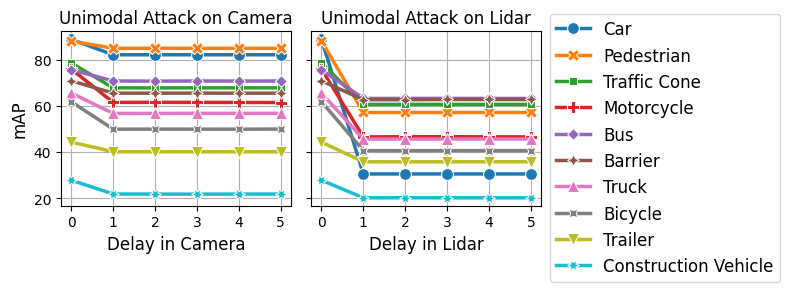

In [48]:
for metric in list_of_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(8, 2.75), sharex=True, sharey=True)
    for ax, (tar_mod, safe_mod) in zip(axes, [['Delay_Camera', 'Delay_Lidar'], ['Delay_Lidar', 'Delay_Camera']]):
        print(f"metric: {metric}")
        
        df = result_total[result_total[safe_mod] == 0]
        df['mAP_label'] = df['mAP_label']*100
        legend_order = df[(df['Delay_Lidar'] == 0) & (df['Delay_Camera'] == 0)].sort_values(['mAP_label'], ascending=False)['Object'].values
        sns.lineplot(
            data=df,
            x=tar_mod,
            y=metric,
            hue='Object',
            style='Object',
            hue_order=legend_order,      # <- Custom order here
            style_order=legend_order,    # <- Keep markers/styles consistent
            markers=True,
            dashes=False,
            linewidth=2.5,
            markersize=8.5,
            ax=ax
        )

        ax.set_xlabel(tar_mod.replace("_", " in "), fontsize=12)
        if ax == axes[0]:
            ax.set_ylabel("mAP", fontsize=12)
            ax.legend().set_visible(False)
        else:
            ax.legend(bbox_to_anchor=(1, 1.15), fontsize=12)
        ax.grid(True)
        target_mod = tar_mod.split("_")[1].capitalize()
        ax.set_title(f"Unimodal Attack on {target_mod}", fontsize=12)
        # ax.set_ylim(0, 100)        # 
        ax.set_xticks([0,1,2,3,4,5])
    plt.tight_layout()
    fig_dir = plot_dir / f"attack_impact_line_{dataset}_{metric}_hue_classes"
    fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
    fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
    plt.show()

In [49]:
# for metric in list_of_metrics:
#     fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey= True)
#     for ax, (tar_mod, safe_mod)  in zip(axes, [['Delay_Camera', 'Delay_Lidar'], ['Delay_Lidar', 'Delay_Camera']]):
#         print(f"metric: {metric}")
#         # Assuming df_melted is already defined
#         df = result_total[result_total[safe_mod] == 0]
#         # df = df.dropna()
#         # Create a catplot
        
#         sns.lineplot(data=df, x=tar_mod, hue='Object', style='Object', y=metric, markers = True, dashes=False, linewidth = 2, markersize= 8, ax = ax) # kind='point', aspect=1.25, height=3.0,
#         # sns.catplot(data=df, x=tar_mod, hue='Object', y=metric, kind='point', aspect=1.25, height=3.0, ax = ax)

#         ax.set_xlabel(tar_mod.replace("_", " in "))
#         if ax == axes[0]:
#             ax.set_ylabel("mAP")
#         if ax == axes[0]:
#             ax.legend().set_visible(False)
#         else:
#             ax.legend(bbox_to_anchor = (1,1))

       
#     # # Save the plot
#     # fig_dir = plot_dir / f'attack_impact_{metric}_image.jpg'
#     # plt.savefig(fig_dir, dpi=350)

#     # Show the plot
#     plt.tight_layout()
#     plt.show()




In [50]:
# # Assuming df_melted is already defined
# df = df_melted[df_melted['Delay_Camera'] == 0]

# # Create a catplot
# ax = sns.catplot(data=df, x='Delay_Lidar', hue='ObjectType', y='mAP_object', kind='point', aspect=1.0, height=3.5)

# # Set the y-axis limits for all subplots
# for axis in ax.axes.flat:
#     axis.set_ylim(0, 1)  # Set y-axis limits (0, 1)
#     axis.grid(True)       # Enable grid
# # Save the plot
# plot_dir = Path(f"../artifacts/{dataset}_plots/attack_impact_lidar.jpg")
# plot_dir.parent.mkdir(exist_ok=True, parents=True)
# plt.savefig(plot_dir, dpi=350)
# # Show the plot
# plt.show()

In [51]:
# # Assuming df_melted is already defined
# df = df_melted[df_melted['Delay_Lidar'] == 0]
# # Create a catplot
# ax = sns.catplot(data=df, x='Delay_Camera', hue='ObjectType', y='mAP_object', kind='point', aspect=1.0, height=3.5)

# # Set the y-axis limits for all subplots
# for axis in ax.axes.flat:
#     axis.set_ylim(0, 1)  # Set y-axis limits (0, 1)
#     axis.grid(True)       # Enable grid
# # Save the plot
# plot_dir = Path(f"../artifacts/{dataset}_plots/attack_impact_camera.jpg")
# plot_dir.parent.mkdir(exist_ok=True, parents=True)
# plt.savefig(plot_dir, dpi=350)
# # Show the plot
# plt.show()

In [52]:
# result_total.iloc[:, 0:-1].groupby(['Delay_Lidar', 'Delay_Camera']).mean()
result_total

,trans_err,scale_err,orient_err,vel_err,attr_err,mAP_label,mAP,NDS,Delay_Lidar,Delay_Camera,Object
car,0.163741,0.149321,0.063760,0.261097,0.189976,0.888321,0.677529,0.709781,0,0,Car
truck,0.303428,0.183595,0.141315,0.246594,0.224778,0.655585,0.677529,0.709781,0,0,Truck
bus,0.314657,0.182688,0.070642,0.490029,0.247338,0.756769,0.677529,0.709781,0,0,Bus
trailer,0.517913,0.223007,0.461781,0.213417,0.174097,0.443365,0.677529,0.709781,0,0,Trailer
construction_vehicle,0.746033,0.441769,0.853518,0.125201,0.273020,0.278159,0.677529,0.709781,0,0,Construction Vehicle
...,...,...,...,...,...,...,...,...,...,...,...
pedestrian,0.195374,0.288839,0.614157,0.278662,0.146315,0.255597,0.274145,0.487041,5,5,Pedestrian
motorcycle,0.229402,0.243796,0.301141,0.346848,0.307323,0.121764,0.274145,0.487041,5,5,Motorcycle
bicycle,0.171994,0.266222,0.326489,0.170829,0.012217,0.204106,0.274145,0.487041,5,5,Bicycle
traffic_cone,0.138235,0.328848,NaN,NaN,NaN,0.360288,0.274145,0.487041,5,5,Traffic Cone


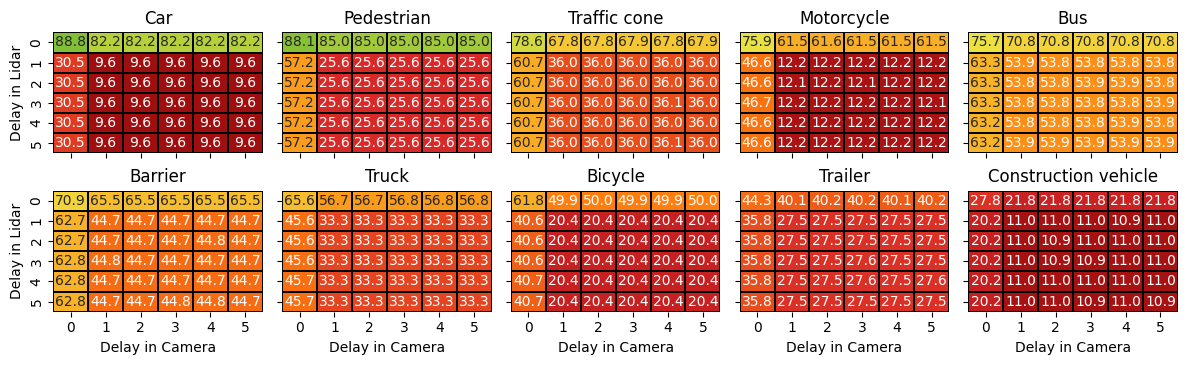

In [53]:
import matplotlib.colors as mcolors
metric = 'mAP_label'
fig, axes = plt.subplots(2, 5, figsize=(12, 3.75), sharex=True, sharey=True)

for ax, class_name in zip(axes.flatten(), legend_order):
    df_class = result_total[result_total['Object'] == class_name]
    df_pivot = df_class.pivot_table(columns ='Delay_Camera', index = 'Delay_Lidar', values = 'mAP_label', aggfunc="mean")*100
    cmap = 'RdYlGn_r' if 'err' in metric else 'RdYlGn' 
    # print(cmap, metric)
    # plt.figure(figsize=(3, 2))
    # Custom colormap with multiple color transitions
    colors = ["#2ca02c", "#f0e442", "#ff7f0e", "#d62728", "#800000"][::-1]  # Green → Yellow → Orange → Red → Dark Red 
    cmap = mcolors.LinearSegmentedColormap.from_list("CustomGreenRed", colors, N=256)

    vmin = df_class[metric].min()*100
    vmax = df_class[metric].max()*100
    vmax = 100.0
    vmin = 0.0
    sns.heatmap(df_pivot, fmt='0.1f', annot=True, cmap=cmap, linewidths=0.10, linecolor='black', cbar=False, vmin=vmin, vmax=vmax,ax=ax) #vmin=vmin, vmax=vmax,
    ax.set_title(" ".join([word.capitalize() for word in class_name.split("_")]))

    if ax in [axes[0, 0], axes[1,0]]:
        ax.set_ylabel("Delay in Lidar")
    else:
        ax.set_ylabel("")

    if ax in axes[1, :].flatten():
        ax.set_xlabel("Delay in Camera")
    else:
        ax.set_xlabel("")
plt.tight_layout()
fig_dir = plot_dir / f"attack_impact_grid_{dataset}_{metric}_all_class"
fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
plt.show()

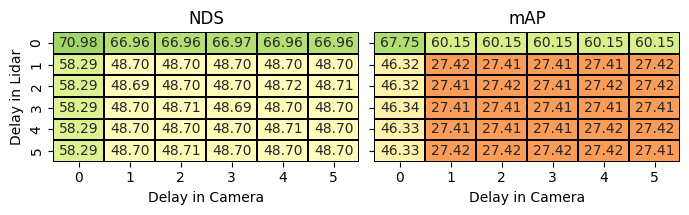

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2.25), sharex=True, sharey=True)
for ax, metric in zip(axes, ['NDS', 'mAP']):
    df_pivot = result_total.pivot_table(columns ='Delay_Camera', index = 'Delay_Lidar', values = metric, aggfunc="mean")*100
    cmap = 'RdYlGn_r' if 'err' in metric else 'RdYlGn' 
    vmin = result_total[metric].min()*100
    vmax = result_total[metric].max()*100
    vmax = 100.0
    vmin = 0.0
    sns.heatmap(df_pivot, fmt='0.2f', annot=True, cmap=cmap, linewidths=0.10, linecolor='black', cbar=False, vmin=vmin, vmax=vmax,ax=ax) #vmin=vmin, vmax=vmax,

    colors = ["#2ca02c", "#f0e442", "#ff7f0e", "#d62728", "#800000"][::-1]  # Green → Yellow → Orange → Red → Dark Red 
    cmap = mcolors.LinearSegmentedColormap.from_list("CustomGreenRed", colors, N=256)


    if ax in [axes[0]]:
        ax.set_ylabel("Delay in Lidar")
    else:
        ax.set_ylabel("")

    if ax in axes:
        ax.set_xlabel("Delay in Camera")
    else:
        ax.set_xlabel("")
    ax.set_title(metric)
    # ax.set_yticks([0,1,2,3,4,5],rotation=90)
plt.tight_layout()
fig_dir = plot_dir / f"attack_impact_grid_{dataset}_{metric}_combined"
fig.savefig(f"{fig_dir}"+".jpg", dpi=350)
fig.savefig(f"{fig_dir}"+".pdf", dpi=350)
plt.show()